# Find worst performing classes by model prediction

Runs a trained model over a full split's test set, ranks glosses by per-class
f1-score, and builds a new `asl100_worst` split from the 100 worst-performing
classes.

In [1]:
import json
from pathlib import Path

from pydantic import BaseModel

#locals
from src.configs import get_class_list
from src.preprocess import Instance
from src.run_types import AVAIL_SPLITS, CUTOFF_9_NAMES, CUTOFF_SPLITS, AdminInfo
from src.stats import AVAIL_SETS, get_all_sets, to_preproc_format
from src.testing import get_res_path
from src.utils import plt_display_grid
from src.video_dataset import get_wlasl_info
from src.visualise2 import FrameFetcher, infer, set_thesis_style

## Setup

In [2]:
set_thesis_style()
verbosity = 1
save_files = False
def printv(*args, level=1, **kwargs):
    if level <= verbosity:
        print(*args, **kwargs)
        
split_idx = 3 #change for different split
split_options: list[CUTOFF_SPLITS] = CUTOFF_9_NAMES
set_options: list[AVAIL_SETS] = ['train', 'test', 'val']
split_name: AVAIL_SPLITS = split_options[split_idx]
set_idx = 1 #change for different set
set_name: AVAIL_SETS = set_options[set_idx]
classes = get_class_list()
check_name = 'best.pth'
printv(f'Split name: {split_name}')
printv(f'Set name: {set_name}')

Split name: asl2000_cutoff_9
Set name: test


## Run inference and rank glosses by f1-score

In [6]:
from src.run_types import SRC_ROOT

admin = AdminInfo.model_validate({
    "model" : "MViTv2_B_32x3",
    "dataset": "WLASL",
    "split": "asl2000_cutoff_9",
    "save_path": str(SRC_ROOT / "runs/asl2000_cutoff_9/MViTv2_B_32x3/exp004/checkpoints"),
    "exp_no": "004",
    "recover": False,
    "config_path": str(SRC_ROOT / "configfiles/asl2000/MViTv2_B_32x3/exp004.toml"),
    "weight_path": "runs/asl1000_cutoff_9/MViTv2_B_32x3/exp001/checkpoints/best.pth"
})
save_path = Path(admin.save_path)

print(f"Testing on {set_name} set")
topk_res, cls_report, all_targets, all_preds = infer(admin, set_name, split_name, check_name=check_name)

Testing on test set


/home/luke/Code/SLR/src/visualise2.py:869: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(Path(admin.save_path) / check_name)
Testing: 100%|██████████

top-k average per class acc: 0.47614999999999996, 0.8120666666666666, 0.8781083333333334
top-k per instance acc: 0.5008683570684266, 0.8134769017019798, 0.8763459534560611
Averag Loss: 2.49


### Stash for offline use

In [ ]:
from src.run_types import RESULTS_OUTPUTS




runs/asl2000_cutoff_9/MViTv2_B_32x3/exp004/results/best_val_loss.json
saved to : runs/asl2000_cutoff_9/MViTv2_B_32x3/exp004/results/topk_cls_report.json and runs/asl2000_cutoff_9/MViTv2_B_32x3/exp004/results/all_targets_preds.json


In [ ]:
metric = 'f1-score'

gloss_metrics = [ 
    (key, item[metric]) for key, item in cls_report.items() if key[0].isdigit()
]

sorted_glosses = sorted(
    gloss_metrics,
    key=lambda x: x[1]
)

bottom_100_label_nums = [
    int(i) for i, _ in sorted_glosses[:100]
]

bottom_100_label_names = [classes[i] for i in bottom_100_label_nums]

printv(gloss_metrics[0])
printv(len(gloss_metrics))
printv(sorted_glosses[0])

('0', 1.0)
2000
('3', 0.0)


## Preview an example clip from a worst-performing class

In [ ]:
target_length = 16
cls_idx = bottom_100_label_nums[1] # change for different class
all_sets = get_all_sets(split_name)
frame_fetcher = FrameFetcher(
    cls_idx=cls_idx,
    all_sets=all_sets,
    set_name=set_name,
    split_name=split_name,
    target_length=target_length,
)

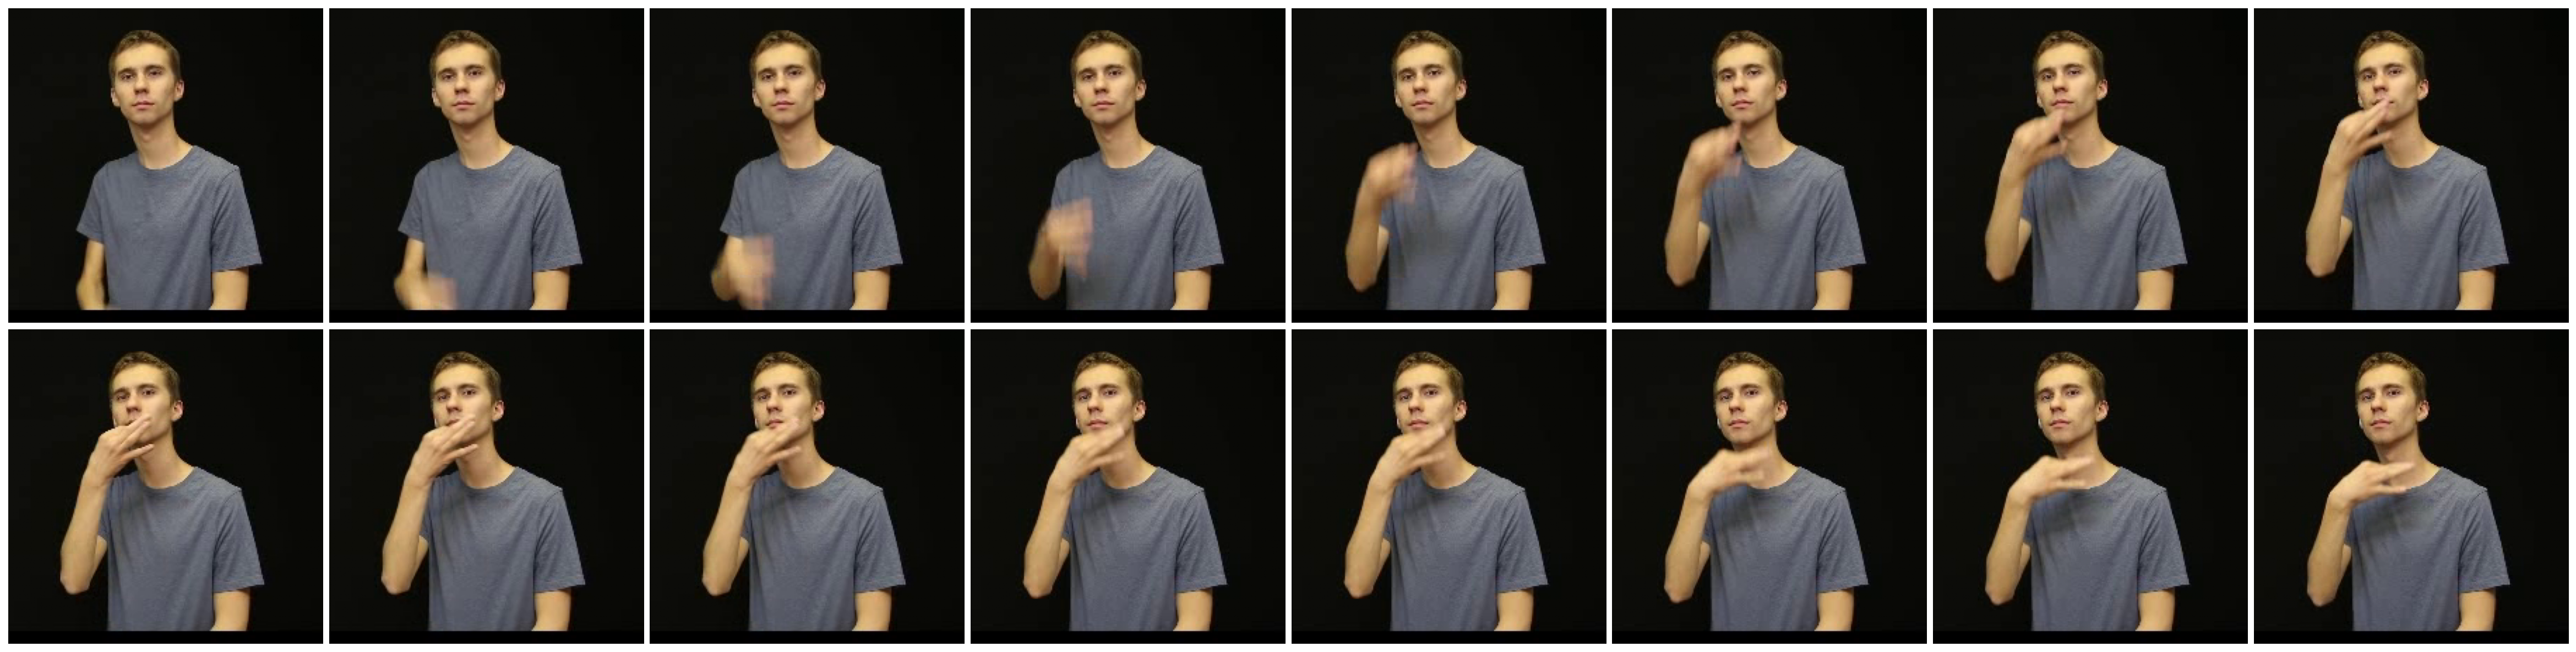

Example videos for class: "thin"
Sample: 1 / 3


In [ ]:
frames = frame_fetcher()
plt_display_grid(frames, num=target_length)
print(f'Example videos for class: "{classes[cls_idx]}"')
print(f'Sample: {frame_fetcher.cur_idx} / {frame_fetcher.len}')

## Build the `asl100_worst` dataset split

Remaps the 100 worst-performing glosses to labels 0-99 (keeping the original
label number for reference) and writes a new label set per split.

In [ ]:
def _pydantic_default(obj):
    if isinstance(obj, BaseModel):
        return obj.model_dump()

def map_new_labels(instances: list[Instance]) -> list[dict]:
    """Need to remap the labels to be from 0-99 instead of the original label nums
    But want to save the original label nums in the instance info as well for reference
    """
    mapped_instances = []
    for inst in instances:
        original_label_num = inst.label_num
        inst_dict = inst.model_dump()
        inst_dict['original_label_num'] = original_label_num
        inst_dict['label_num'] = bottom_100_label_nums.index(original_label_num)
        mapped_instances.append(inst_dict)
        
    return mapped_instances
        

split_name = 'asl100_cutoff_9'
new_split_name = 'asl100_worst'
new_suffix = f'{metric}_{admin.model}_{admin.split}_{admin.exp_no}.json'
for set_name in set_options:
    bottom_100_subset = to_preproc_format(
        all_sets[set_name],
        criterion=lambda x: x['gloss'] in bottom_100_label_names
    )
    bottom_100_mapped = map_new_labels(bottom_100_subset)
    
    
    
    original_set_path_info = get_wlasl_info(split_name, set_name)
    new_dir = original_set_path_info['labels'].parent / new_split_name 
    # new_dir = Path('preprocessed/labels/asl_100_worst/')
    new_path = new_dir / f'{set_name}_{new_suffix}'
    
    new_dir.mkdir(exist_ok=True, parents=True)
    with open(new_path, 'w') as f:
        json.dump(bottom_100_mapped, f, indent=2, default=_pydantic_default)
    printv(f'Saved to: {new_path}')

Saved to: /home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100_worst/train_f1-score_MViTv2_B_32x3_asl2000_cutoff_9_004.json
Saved to: /home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100_worst/test_f1-score_MViTv2_B_32x3_asl2000_cutoff_9_004.json
Saved to: /home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100_worst/val_f1-score_MViTv2_B_32x3_asl2000_cutoff_9_004.json
